# Figure 1

This notebook reproduces the numbers in **Figure 1b** (dataset summary) and **Figure 1c** (overlap of SGBs between lifestyles), and the rarefaction curves in **Figure 1d**.

Inputs are the SGB database (Jan21 release) and the sample metadata table. Their paths are set in the first code cell.

In [1]:
import bz2
import random
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

SGB_DB = '../data/SGB.Jan21.txt.bz2' # MetaRefSGB data
METADATA = '../data/nw_metadata.tsv' # complete metadata table

SEED = 42 
N_REPLICATES = 99       # random draws per number of studies
SAMPLES_PER_STUDY = 20  # maximum samples drawn from each study

COLORS = {'Westernized': '#2b8cbe', 'Non-Westernized': '#d0d000'}

## Load data

For each SGB we keep its MAGs and whether it has at least one reference genome (kSGB) or none (uSGB). MAG names have the form `<study>__<sample>__<bin>`, which links each MAG to the sample it was reconstructed from. Each sample is then assigned the set of SGBs with at least one MAG from that sample.

In [2]:
sgb_mags = {}      # SGB id -> MAG names
sgb_is_known = {}  # SGB id -> True for kSGBs (>= 1 reference genome), False for uSGBs
with bz2.open(SGB_DB, 'rt') as fh:
    for line in fh:
        if line.startswith('GGB'):
            break
        if line.startswith('SGB'):
            fields = line.strip().split('\t')
            sgb_mags[fields[1]] = [x for x in fields[4].split(',') if x != '-']
            sgb_is_known[fields[1]] = any(x != '-' for x in fields[5].split(','))


def sample_key(study, sample):
    return f'{study}__{sample}__'


sample_sgbs = defaultdict(set)  # sample key -> SGBs with >= 1 MAG from that sample
for sgb, mags in sgb_mags.items():
    for mag in mags:
        parts = mag.split('__')
        if len(parts) > 1:
            sample_sgbs[sample_key(parts[0], parts[1])].add(sgb)
sample_sgbs = dict(sample_sgbs)

metadata = pd.read_table(METADATA)
w_meta = metadata[metadata['non_westernized'] == 'no']
nw_meta = metadata[metadata['non_westernized'] == 'yes']
a_meta = metadata[metadata['non_westernized'] == 'ancient']

## Panel b

Number of samples, studies, countries and continents in each lifestyle group, taken from the metadata. Continents follow the five-continent convention, with North and South America counted together as America. The age range of the ancient samples (5,300 to 250 years ago) comes from the original publications and is not computed here.

In [3]:
CONTINENT = {
    **dict.fromkeys(['AUT', 'BEL', 'BGR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR',
                     'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LTU', 'LUX', 'LVA', 'NLD', 'NOR', 'POL',
                     'PRT', 'ROU', 'RUS', 'SRB', 'SVK', 'SVN', 'SWE', 'UKR'], 'Europe'),
    **dict.fromkeys(['BGD', 'BTN', 'CHN', 'IDN', 'IND', 'IRN', 'ISR', 'JPN', 'KAZ', 'KGZ', 'KOR', 'LBN',
                     'LKA', 'MNG', 'MYS', 'NPL', 'PAK', 'PHL', 'SAU', 'SGP', 'THA', 'TUR', 'TWN', 'VNM'], 'Asia'),
    **dict.fromkeys(['BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
                     'GNB', 'KEN', 'MDG', 'MLI', 'MOZ', 'MWI', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'TCD',
                     'TGO', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE'], 'Africa'),
    **dict.fromkeys(['ARG', 'BOL', 'BRA', 'CAN', 'CHL', 'COL', 'CRI', 'CUB', 'ECU', 'GTM', 'GUY', 'HND',
                     'HTI', 'MEX', 'NIC', 'PAN', 'PER', 'PRY', 'SLV', 'URY', 'USA', 'VEN'], 'America'),
    **dict.fromkeys(['AUS', 'FJI', 'NZL', 'PNG', 'SLB', 'VUT', 'WSM'], 'Oceania'),
}


def summarize(meta, geography=True):
    summary = {'Metagenomic samples': len(meta), 'Studies': meta['study_name'].nunique()}
    if geography:
        countries = set(meta['country'].dropna())
        unassigned = sorted(countries - set(CONTINENT))
        if unassigned:
            raise KeyError(f'Add these countries to CONTINENT: {unassigned}')
        summary['Countries'] = len(countries)
        summary['Continents'] = len({CONTINENT[c] for c in countries})
    return {k: f'{v:,}' for k, v in summary.items()}


pd.DataFrame({
    'Westernized lifestyle': summarize(w_meta),
    'Non-Westernized lifestyle': summarize(nw_meta),
    'Ancient origin': summarize(a_meta, geography=False),
}).fillna('')

,Westernized lifestyle,Non-Westernized lifestyle,Ancient origin
Metagenomic samples,"11,123","1,718",29
Studies,59,22,7
Countries,25,15,
Continents,3,4,


## Samples and SGBs per lifestyle

Westernized study names in the metadata are matched to the names used in the SGB database. All samples from AsnicarF_2020, Heitz-BuschartA_2016 and HMP2 in the SGB database are also counted as Westernized. Only samples with at least one MAG contribute SGBs.

In [4]:
W_STUDY_RENAME = {
    'ThomasAM_2019_a': 'ThomasAM_2019',
    'ThomasAM_2019_b': 'ThomasAM_2019',
    'ThomasAM_2019_c': 'ThomasAM_2019',
    'BengtssonPalmeJ_2015': 'Bengtsson-PalmeJ_2015',
    'CM_caritro': 'FerrettiP_2018',
    'LawrenceA_2015': 'DavidLA_2015',
}
W_EXTRA_STUDIES = ('AsnicarF_2020', 'Heitz-BuschartA_2016', 'HMP2')


def keys_from_metadata(meta, rename=None):
    study = meta['study_name'].replace(rename) if rename else meta['study_name']
    return set(study + '__' + meta['sample_id'].astype(str) + '__')


def sgbs_per_sample(keys):
    return {k: sample_sgbs[k] for k in keys if k in sample_sgbs}


w_keys = keys_from_metadata(w_meta, W_STUDY_RENAME) | {k for k in sample_sgbs if k.startswith(W_EXTRA_STUDIES)}
w_sample_sgbs = sgbs_per_sample(w_keys)
nw_sample_sgbs = sgbs_per_sample(keys_from_metadata(nw_meta))
a_sample_sgbs = sgbs_per_sample(keys_from_metadata(a_meta))

## Panel c

Number of SGBs in each region of the Venn diagram.

In [5]:
W, NW, A = (set().union(*d.values()) for d in (w_sample_sgbs, nw_sample_sgbs, a_sample_sgbs))

venn = {
    'Westernized only': W - NW - A,
    'Westernized & Non-Westernized': (W & NW) - A,
    'Non-Westernized only': NW - W - A,
    'Westernized & Ancient': (W & A) - NW,
    'All three': W & NW & A,
    'Non-Westernized & Ancient': (NW & A) - W,
    'Ancient only': A - W - NW,
}
pd.DataFrame({'SGBs': {region: f'{len(sgbs):,}' for region, sgbs in venn.items()}})

,SGBs
All three,38
Ancient only,46
Non-Westernized & Ancient,9
Non-Westernized only,"1,372"
Westernized & Ancient,3
Westernized & Non-Westernized,"1,409"
Westernized only,"2,546"


## Panel d

Rarefaction by study. For each number of studies *n*, we draw *n* studies at random, then up to 20 samples from each, and count the distinct SGBs among their MAGs. This is repeated 99 times for each *n*. Lines show the mean and bands show ± 1 SD. The x-axis is *n* × 20 samples; a study with fewer than 20 samples contributes all of them. The dashed line marks the largest non-Westernized value.

In [6]:
def rarefaction(studies, group_sample_sgbs, rng):
    study_samples = defaultdict(list)
    for key in sorted(group_sample_sgbs):
        study_samples[key.split('__')[0]].append(key)
    rows = []
    for n in range(1, len(studies) + 1):
        for _ in range(N_REPLICATES):
            found = set()
            for study in rng.sample(studies, n):
                samples = study_samples.get(study, [])
                for key in rng.sample(samples, min(len(samples), SAMPLES_PER_STUDY)):
                    found |= group_sample_sgbs[key]
            n_known = sum(sgb_is_known[sgb] for sgb in found)
            rows.append((n, len(found), n_known, len(found) - n_known))
    return pd.DataFrame(rows, columns=['studies', 'All SGBs', 'kSGBs', 'uSGBs'])


# Westernized: studies with at least one MAG. Non-Westernized: all studies in the metadata.
w_studies = sorted({k.split('__')[0] for k in w_sample_sgbs})
nw_studies = sorted(nw_meta['study_name'].unique())

rng = random.Random(SEED)
curves = pd.concat([
    rarefaction(w_studies, w_sample_sgbs, rng).assign(lifestyle='Westernized'),
    rarefaction(nw_studies, nw_sample_sgbs, rng).assign(lifestyle='Non-Westernized'),
])
curves['samples'] = curves['studies'] * SAMPLES_PER_STUDY

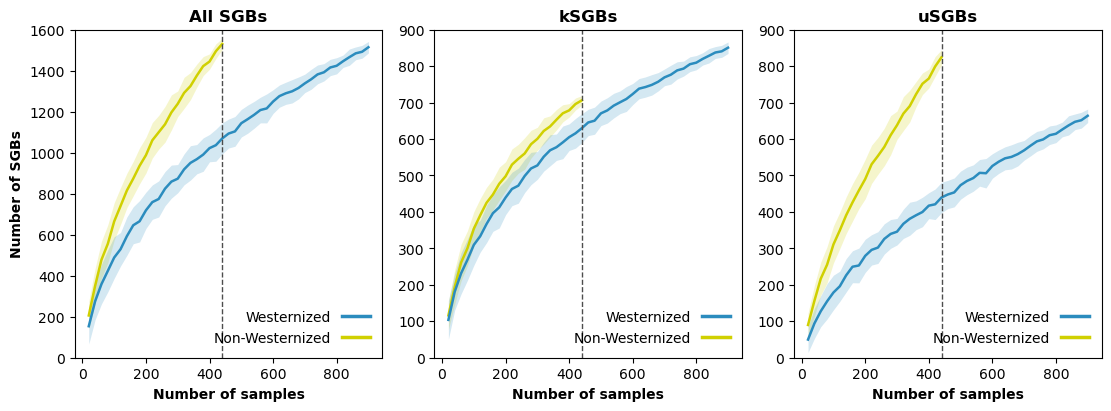

In [7]:
PANELS = [('All SGBs', 1600, 200), ('kSGBs', 900, 100), ('uSGBs', 900, 100)]
stats = curves.groupby(['lifestyle', 'samples'])[[p[0] for p in PANELS]].agg(['mean', 'std'])
nw_end = len(nw_studies) * SAMPLES_PER_STUDY
legend_handles = [Line2D([], [], color=COLORS[l], linewidth=2.5, label=l) for l in ('Westernized', 'Non-Westernized')]

fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
for ax, (sgb_type, ymax, ystep) in zip(axes, PANELS):
    for lifestyle in ('Non-Westernized', 'Westernized'):
        s = stats.loc[lifestyle][sgb_type]
        ax.fill_between(s.index, s['mean'] - s['std'], s['mean'] + s['std'],
                        color=COLORS[lifestyle], alpha=0.2, linewidth=0)
        ax.plot(s.index, s['mean'], color=COLORS[lifestyle], linewidth=1.8)
    ax.axvline(nw_end, color='0.3', linestyle='--', linewidth=1)
    ax.set_title(sgb_type, fontweight='bold')
    ax.set_xlabel('Number of samples', fontweight='bold')
    ax.set_ylim(0, ymax)
    ax.xaxis.set_major_locator(MultipleLocator(200))
    ax.yaxis.set_major_locator(MultipleLocator(ystep))
    ax.legend(handles=legend_handles, loc='lower right', frameon=False, markerfirst=False)
axes[0].set_ylabel('Number of SGBs', fontweight='bold')
plt.show()